In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/fuel-prices-for-be-assessment.csv')
df.shape, df.dtypes, df.head()

((8151, 7),
 OPIS Truckstop ID      int64
 Truckstop Name           str
 Address                  str
 City                     str
 State                    str
 Rack ID                int64
 Retail Price         float64
 dtype: object,
    OPIS Truckstop ID             Truckstop Name  \
 0                  7      WOODSHED OF BIG CABIN   
 1                  9             KWIK TRIP #796   
 2                 20  PILOT TRAVEL CENTER #1243   
 3                 20                PILOT #1243   
 4                 28     LITTLEFIELD EXPRESS #2   
 
                           Address        City State  Rack ID  Retail Price  
 0          I-44, EXIT 283 & US-69   Big Cabin    OK      307      3.007333  
 1  I-94, EXIT 143 & US-12 & SR-21       Tomah    WI      420      3.287333  
 2           I-8, EXIT 119 & SR-85   Gila Bend    AZ      930      3.899000  
 3           I-8, EXIT 119 & SR-85   Gila Bend    AZ      930      3.899000  
 4          I-540, EXIT 12 & US-71  Fort Smith    AR      

In [29]:
df.isnull().sum()

OPIS Truckstop ID    0
Truckstop Name       0
Address              0
City                 0
State                0
Rack ID              0
Retail Price         0
dtype: int64

In [30]:
df.columns.tolist()

['OPIS Truckstop ID',
 'Truckstop Name',
 'Address',
 'City',
 'State',
 'Rack ID',
 'Retail Price']

In [31]:
len(df), df['OPIS Truckstop ID'].nunique()

(8151, 6738)

In [32]:
duplicates = df[df.duplicated(subset=['OPIS Truckstop ID'], keep=False)].sort_values(by='OPIS Truckstop ID')
duplicates.head(20)

,OPIS Truckstop ID,Truckstop Name,Address,City,State,Rack ID,Retail Price
2,20,PILOT TRAVEL CENTER #1243,"I-8, EXIT 119 & SR-85",Gila Bend,AZ,930,3.899000
3,20,PILOT #1243,"I-8, EXIT 119 & SR-85",Gila Bend,AZ,930,3.899000
18,105,TA SAGINAW I 75 TRAVEL CENTER,"I-75, EXIT 144-B",Bridgeport,MI,260,3.269000
19,105,TA SAGINAW I 75 TRAVEL CENTER,"I-75, EXIT 144-B",Bridgeport,MI,260,3.339000
20,105,TA SAGINAW I 75 TRAVEL CENTER,"I-75, EXIT 144-B",Bridgeport,MI,260,3.429000
21,105,TA SAGINAW I 75 TRAVEL CENTER,"I-75, EXIT 144-B",Bridgeport,MI,260,3.289000
22,105,TA SAGINAW I 75 TRAVEL CENTER,"I-75, EXIT 144-B",Bridgeport,MI,260,3.399000
23,105,TA SAGINAW I 75 TRAVEL CENTER,"I-75, EXIT 144-B",Bridgeport,MI,260,3.299000
27,128,THE EFFINGHAM CHROME SHOP,"I-57 & I-70, EXIT 159",Effingham,IL,510,3.399000
28,128,THE EFFINGHAM CHROME SHOP,"I-57 & I-70, EXIT 159",Effingham,IL,510,3.349000


In [33]:
g = df.groupby('OPIS Truckstop ID')['Retail Price'].agg({'min', 'max', 'count'})
(g['max'] - g['min']).describe()

count    6738.000000
mean        0.010158
std         0.046178
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.900000
dtype: float64

<Axes: >

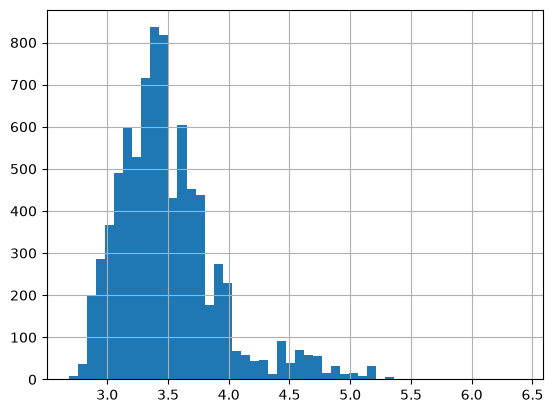

In [34]:
df['Retail Price'].describe()
df['Retail Price'].hist(bins=50)

In [35]:
df['State'].value_counts()

State
TX    790
IL    774
MI    327
GA    311
WI    297
OH    263
MO    250
IN    238
IA    233
FL    220
PA    217
ON    217
VA    205
LA    196
NC    195
OK    182
SC    182
AB    180
MN    175
AL    170
AZ    163
TN    162
NY    158
MS    141
KS    132
AR    125
KY    122
BC    121
NJ    112
NE    111
NM    107
CO    103
UT     98
WA     97
NV     71
WY     66
ID     65
MD     64
SD     62
ND     59
MT     44
MA     44
MB     42
WV     39
SK     36
ME     30
OR     29
CT     27
NH     23
DE     18
VT     16
CA     16
YT      8
QC      6
NS      6
NB      4
RI      2
Name: count, dtype: int64

In [36]:
pairs = df[['City', 'State']].drop_duplicates()
len(pairs)

4275

In [37]:
pairs.sample(20)

,City,State
515,Seguin,TX
2577,Romulus,MI
1663,Laredo,TX
5072,Brainerd,MN
1942,Walnut,MS
492,Bald Knob,AR
7322,East Dublin,GA
389,Saint Cloud,MN
3413,Bethel,PA
2633,Clarksville,AR


In [38]:
ca = {'ON','AB','BC','MB','SK','YT','QC','NS','NB'}
us = df[~df['State'].isin(ca)].copy()
us['City'] = us['City'].str.strip()
len(df) - len(us), us['OPIS Truckstop ID'].nunique(), len(us[['City','State']].drop_duplicates())

(620, 6626, 3813)

In [39]:
us.to_csv('../data/fuel_prices_clean_us.csv', index=False)

In [40]:
import re

REPLACEMENTS = [(r"\bSAINT\b", "ST"), (r"\bFORT\b", "FT"), (r"\bMOUNT\b", "MT")]

def normalize_place_name(name):
    name = name.upper().replace(".", "").replace("'", "").replace("-", " ")
    for pattern, repl in REPLACEMENTS:
        name = re.sub(pattern, repl, name)
    return " ".join(name.split())

In [41]:
us["key_city"] = us["City"].map(normalize_place_name)
us.head(20)

,OPIS Truckstop ID,Truckstop Name,Address,City,State,Rack ID,Retail Price,key_city
0,7,WOODSHED OF BIG CABIN,"I-44, EXIT 283 & US-69",Big Cabin,OK,307,3.007333,BIG CABIN
1,9,KWIK TRIP #796,"I-94, EXIT 143 & US-12 & SR-21",Tomah,WI,420,3.287333,TOMAH
2,20,PILOT TRAVEL CENTER #1243,"I-8, EXIT 119 & SR-85",Gila Bend,AZ,930,3.899000,GILA BEND
3,20,PILOT #1243,"I-8, EXIT 119 & SR-85",Gila Bend,AZ,930,3.899000,GILA BEND
4,28,LITTLEFIELD EXPRESS #2,"I-540, EXIT 12 & US-71",Fort Smith,AR,645,3.399000,FT SMITH
5,35,ACI TRUCK STOP,US-46,Columbia,NJ,90,3.079000,COLUMBIA
6,36,SHENANDOAH TRUCK CENTER,"I-81, EXIT 273 & SR-703/SR-292",Mount Jackson,VA,60,2.899000,MT JACKSON
7,44,CIRCLE K #2612042,"I-35, EXIT 271",Jarrell,TX,595,2.919000,JARRELL
8,46,PETRO STOPPING CENTER #348,"I-85, EXIT 22 & CR-138",Shorter,AL,720,3.154000,SHORTER
9,49,TA SEYMOUR TRAVEL CENTER,"I-65, EXIT 50 & US-50 & US-31",Seymour,IN,415,3.959000,SEYMOUR


### Fuel price exploration

- **8,151 rows, 6,738 unique stations** (`OPIS Truckstop ID`), no null values. Some IDs appear
  up to 6 times, with name variations ("PILOT #1243" / "PILOT TRAVEL CENTER #1243") or different prices.
  Duplicated IDs always share the same city and state.
- **Duplicates: keep the minimum price.** In most cases the price is identical (median max−min
  spread per station: $0.00, mean: $0.01; worst case: $0.90). Differences most likely come from
  multiple price readings for the same station, and a driver would pay the lowest available price.
- **Exclude 620 rows from Canada** (ON, AB, BC, MB, SK, YT, QC, NS, NB): routes are US-only and
  those prices belong to a different market. **6626 US stations remain.**
- **3813 unique city/state pairs to geocode**, after `strip()` (the `City` column has trailing
  whitespace, e.g. "Effingham        ") and after excluding Canada.
- **Geocoding is done at city level, not by address.** Addresses look like "I-44, EXIT 283 & US-69"
  and can't be geocoded reliably. City-level precision is enough to choose where to refuel, and it's
  why the API later accepts stations within ~10 miles of the route.